# Sélection de variables pour le clustering flou — Benchmark comparatif

**Auteur : Alice Lemaire** — CentraleSupélec, Pole Projet IA & ML


**Projet CEA-LIST** | Université Paris-Saclay

---

## 1. Introduction

### 1.1 Contexte

Le CEA-LIST a développé un algorithme d'aide à la décision pour l'optimisation expérimentale en science des matériaux (Rousselle, Poli & Ben Abdallah, 2024). Cet algorithme repose sur un **clustering flou** (Fuzzy C-Means) couplé à un système d'inférence de Sugeno, et produit des **règles interprétables** de la forme :

> *Si $x_1$ est ÉLEVÉ $\wedge$ $x_3$ est BAS $\rightarrow$ $y$ est FORT*

Chaque règle comporte **autant de conditions que de variables** $N$ dans le jeu de données. Lorsque $N$ est élevé (jusqu'à 135 pour certains jeux de données), les règles deviennent illisibles et l'avantage principal de l'approche — l'interprétabilité — est perdu.

### 1.2 L'algorithme du CEA en 4 étapes

| Étape | Description | Formulation |
|:-----:|-------------|-------------|
| 1 | **Clustering flou (FCM)** | Minimise $J = \sum_{i} \sum_{c} \mu_{ci}^{m} \|x_i - m_c\|^2$ sous contrainte $\sum_c \mu_{ci} = 1$ |
| 2 | **Prédiction (Sugeno)** | $\hat{y}(x) = \sum_c \mu_c(x) \cdot (\alpha_c^\top x + \beta_c)$ |
| 3 | **Recommandation** | $S(x) = \hat{y}(x) + \lambda \cdot d(x)$ (exploitation + exploration) |
| 4 | **Interprétabilité** | Projection des centres sur chaque axe $\rightarrow$ ensembles flous triangulaires $\rightarrow$ règles à $N$ conditions |

### 1.3 Objectif

L'objectif de ce travail est d'**identifier les méthodes de sélection de variables les plus adaptées** pour réduire $N$ en amont du clustering, afin que les règles produites soient courtes tout en préservant la qualité du clustering.

### 1.4 Protocole expérimental

Ce notebook constitue le **benchmark comparatif complet** :

- **8 méthodes de sélection** couvrant les 3 familles (Filter, Wrapper, Embedded) + 1 baseline
- **3 méthodes de clustering** : K-Means, Hiérarchique (Ward), Fuzzy C-Means
- **10 jeux de données** (4 matériaux + 6 classification)
- **270 expériences** au total (9 versions des données × 3 clusterings × 10 datasets)

Méthodes écartées : Forward/Backward Selection (complexité $O(d^2)$ prohibitive pour $d=135$) et LFSBSS (insuffisamment documenté dans la littérature).

---
## 2. Environnement technique

### 2.1 Dépendances

In [51]:
# Vérification et installation des dépendances
import subprocess, sys

packages = {"numpy":"numpy", "pandas":"pandas", "sklearn":"scikit-learn",
            "scipy":"scipy", "matplotlib":"matplotlib", "seaborn":"seaborn"}

missing = []
for import_name, pip_name in packages.items():
    try:
        __import__(import_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installation de : {', '.join(missing)}")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install"] + missing + ["-q"])
    except Exception:
        raise ImportError(
            f"Packages manquants : {', '.join(missing)}\n"
            f"Installation manuelle requise : pip install {' '.join(missing)}")

print("Toutes les dépendances sont disponibles.")

Toutes les dépendances sont disponibles.


### 2.2 Imports et configuration

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time, csv as csv_mod

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph
from sklearn.linear_model import Lasso
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

# Configuration graphique
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 100
})
sns.set_style("whitegrid")

# Palette de couleurs par famille de méthode
COLOR_MAP = {
    'Original':           '#9E9E9E',
    'Variance Threshold': '#1976D2',   # Filter
    'Corrélation':        '#42A5F5',   # Filter
    'Laplacian Score':    '#0D47A1',   # Filter
    'SPEC':               '#5C6BC0',   # Filter
    'Sparse K-Means':     '#2E7D32',   # Wrapper
    'MCFS':               '#1565C0',   # Filter
    'FWKM':               '#E65100',   # Embedded
    'PCA (baseline)':     '#C62828',   # Transformation
}
SELECTION_METHODS = list(COLOR_MAP.keys())

---
## 3. Jeux de données

### 3.1 Description

Les 10 jeux de données se répartissent en deux catégories :

| Catégorie | Usage | Métriques d'évaluation |
|-----------|-------|----------------------|
| **Matériaux** (régression) | Cas d'usage réel du CEA | Silhouette, Davies-Bouldin, Calinski-Harabasz |
| **Classification** | Validation de la généralité | Idem + ARI, NMI (comparaison avec les labels réels) |

**Remarque importante** : le clustering ne reçoit **jamais** la variable cible. Celle-ci est réservée à l'évaluation *a posteriori*.

In [53]:
DATA_DIR = "Datasets" + os.sep

if not os.path.isdir("Datasets"):
    raise FileNotFoundError(
        "Le dossier 'Datasets/' est introuvable.\n"
        "Structure attendue :\n"
        "  ./CEA_LIST_Benchmark_FINAL.ipynb\n"
        "  ./Datasets/*.csv")

DATASETS_CONFIG = {
    "UCI_concrete":    {"file":"MAT_UCI_concrete.csv",   "target":"Concrete compressive strength (MPa)", "task":"regression",     "n_clusters":3},
    "Li2023":          {"file":"MAT_Li2023.csv",         "target":"Concrete Strength (MPa)",              "task":"regression",     "n_clusters":3},
    "expt_gap":        {"file":"MAT_expt_gap.csv",       "target":"gap expt",                             "task":"regression",     "n_clusters":5},
    "matbench_steels": {"file":"MAT_matbench_steels.csv", "target":"strength (MPa)",                      "task":"regression",     "n_clusters":3},
    "vehicle":         {"file":"RW_vehicle.csv",         "target":"class",                                "task":"classification", "n_clusters":4},
    "parkinsons":      {"file":"RW_parkinsons.csv",      "target":"status",                               "task":"classification", "n_clusters":2},
    "diabetes":        {"file":"RW_diabetes.csv",        "target":"Outcome",                              "task":"classification", "n_clusters":2},
    "breast_cancer":   {"file":"RW_breast_cancer.csv",   "target":"class",                                "task":"classification", "n_clusters":2},
    "glass":           {"file":"RW_glass.csv",           "target":"Type",                                 "task":"classification", "n_clusters":6},
    "covertype":       {"file":"RW_covertype.csv",       "target":"Cover_Type",                           "task":"classification", "n_clusters":7},
}

### 3.2 Chargement

Traitements spécifiques au chargement :
- **matbench_steels** : 115 lignes malformées dans le CSV (nombre de colonnes incohérent) — filtrées au chargement.
- **covertype** : 581 012 lignes — sous-échantillonné à 5 000 lignes pour des raisons de temps de calcul.

In [54]:
raw_data = {}

for name, cfg in DATASETS_CONFIG.items():
    path = DATA_DIR + cfg["file"]
    
    if name == "covertype":
        df = pd.read_csv(path, encoding='utf-8-sig')
        df = df.sample(n=5_000, random_state=RANDOM_STATE).reset_index(drop=True)
        print(f"  {name:20s} | {str(df.shape):12s} | sous-échantillonné (5 000 / 581 012)")
    elif name == "matbench_steels":
        rows = []
        with open(path, 'r', encoding='utf-8-sig') as f:
            reader = csv_mod.reader(f)
            header = next(reader)
            for row in reader:
                if len(row) == len(header):
                    rows.append(row)
        df = pd.DataFrame(rows, columns=header).apply(pd.to_numeric, errors='coerce')
        print(f"  {name:20s} | {str(df.shape):12s} | {312 - len(rows)} lignes malformées retirées")
    else:
        df = pd.read_csv(path, encoding='utf-8-sig')
        print(f"  {name:20s} | {str(df.shape):12s}")
    
    raw_data[name] = df

print(f"\n{len(raw_data)} jeux de données chargés.")

  UCI_concrete         | (1030, 9)   
  Li2023               | (954, 17)   
  expt_gap             | (4604, 136) 
  matbench_steels      | (197, 13)    | 115 lignes malformées retirées
  vehicle              | (846, 19)   
  parkinsons           | (195, 23)   
  diabetes             | (768, 9)    
  breast_cancer        | (286, 10)   
  glass                | (214, 10)   
  covertype            | (5000, 55)   | sous-échantillonné (5 000 / 581 012)

10 jeux de données chargés.


---
## 4. Prétraitement

Le prétraitement suit les 5 étapes définies dans le document de référence :

1. **Séparation** features / variable cible
2. **Nettoyage** : remplacement des zéros physiologiquement impossibles (`diabetes`), suppression de la classe singleton (`vehicle`), filtrage des lignes corrompues (`matbench_steels`)
3. **Imputation** des valeurs manquantes par la médiane (variables numériques) ou le mode (variables catégorielles)
4. **Encodage** des variables catégorielles : encodage ordinal pour les variables à ordre naturel (`age`, `tumor_size`, `inv_nodes`), one-hot pour les variables nominales (`breast_cancer`)
5. **Normalisation** par `StandardScaler` (centrage-réduction, $\mu=0$, $\sigma=1$)

La normalisation est indispensable car les méthodes basées sur la distance euclidienne (K-Means, FCM) et sur la variance (Variance Threshold) sont sensibles à l'échelle des variables.

In [55]:
processed_data = {}

for name, df_raw in raw_data.items():
    cfg = DATASETS_CONFIG[name]
    df = df_raw.copy()
    
    # Nettoyage spécifique
    if name == "diabetes":
        for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
            df[col] = df[col].replace(0, np.nan)
    elif name == "vehicle":
        df = df[df['class'] != '204'].dropna().reset_index(drop=True)
    
    # Séparation features / cible
    y = df[cfg["target"]].copy()
    X = df.drop(columns=[cfg["target"]]).copy()
    if y.dtype == 'object':
        y = pd.Series(LabelEncoder().fit_transform(y))
    
    # Encodage breast_cancer
    if name == "breast_cancer":
        for col, cats in {'age':['20-29','30-39','40-49','50-59','60-69','70-79'],
            'tumor_size':['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54'],
            'inv_nodes':['0-2','3-5','6-8','9-11','12-14','15-17','24-26']}.items():
            existing = [c for c in cats if c in X[col].values]
            X[col] = pd.Categorical(X[col], categories=existing, ordered=True).codes.astype(float)
            X[col] = X[col].replace(-1, np.nan)
        X = pd.get_dummies(X, columns=['menopause','node_caps','breast','breast_quad','irradiat'],
                          drop_first=True, dtype=float)
    
    # Imputation
    for col in X.select_dtypes(include=[np.number]).columns:
        if X[col].isnull().any():
            X[col] = X[col].fillna(X[col].median())
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    
    # Normalisation
    feat_names = list(X.columns)
    X_scaled = StandardScaler().fit_transform(X)
    
    processed_data[name] = {
        "X": X_scaled,
        "X_df": pd.DataFrame(X_scaled, columns=feat_names),
        "y": y.values,
        "feature_names": feat_names,
        "d_original": X_scaled.shape[1],
        "n_samples": X_scaled.shape[0],
        "task": cfg["task"],
        "n_clusters": cfg["n_clusters"]
    }

# Tableau récapitulatif
recap = []
for name, d in processed_data.items():
    recap.append({
        "Dataset": name,
        "n (échantillons)": d["n_samples"],
        "d (variables)": d["d_original"],
        "Type": d["task"],
        "k (clusters)": d["n_clusters"],
    })
display(pd.DataFrame(recap).set_index("Dataset"))

,n (échantillons),d (variables),Type,k (clusters)
Dataset,,,,
UCI_concrete,1030,8,regression,3
Li2023,954,16,regression,3
expt_gap,4604,135,regression,5
matbench_steels,197,12,regression,3
vehicle,845,18,classification,4
parkinsons,195,22,classification,2
diabetes,768,8,classification,2
breast_cancer,286,13,classification,2
glass,214,9,classification,6


---
## 5. Méthodes de sélection de variables

### 5.1 Classification des approches

Les méthodes de sélection pour le clustering se classent en trois familles (Alelyani et al., 2018) :

| Famille | Principe | Avantage | Limite |
|---------|----------|----------|--------|
| **Filter** | Évalue chaque variable indépendamment du clustering | Rapide, générique | Ignore la structure de cluster |
| **Wrapper** | Utilise un algorithme de clustering comme fonction d'évaluation | Tient compte de la structure | Plus coûteux, dépend du clustering |
| **Embedded** | Intègre la sélection directement dans le processus de clustering | Résout le problème de circularité | Complexité d'implémentation |

On ajoute une **baseline par transformation** (PCA) qui sert de référence : toute méthode de sélection faisant moins bien que PCA est considérée comme non pertinente.

**Le problème de circularité** (dilemme poule/œuf) : pour sélectionner les variables pertinentes, il faudrait connaître les clusters ; mais pour obtenir de bons clusters, il faudrait connaître les variables pertinentes. Les méthodes Embedded résolvent ce problème en optimisant conjointement.

---
### 5.2 Méthode 1 — Variance Threshold (Filter)

**Principe** : éliminer toute variable dont la variance est inférieure à un seuil $\theta$.

$$\text{Conserver la variable } j \iff \text{Var}(x_j) = \frac{1}{n}\sum_{i=1}^{n} (x_{ij} - \bar{x}_j)^2 > \theta$$

Avec $\theta = 0$, seules les constantes pures sont éliminées. Avec $\theta = 0.1$ (valeur retenue), les variables quasi-constantes sont également supprimées.

**Pertinence pour le projet** : le jeu de données `expt_gap` contient 37 variables à variance nulle (fractions d'éléments rares : He, Ne, Ar, Kr, éléments radioactifs). Leur suppression réduit la longueur des règles de 37 conditions sans perte d'information.


**Note** : après normalisation par StandardScaler, toutes les variables non-constantes ont une variance de 1. Le seuil θ = 0.1 n'élimine donc en pratique que les variables de variance nulle (constantes pures avant normalisation).

In [56]:
# Méthode 1 : Variance Threshold (theta = 0.1)
THETA = 0.1
variance_selected = {}

print(f"Variance Threshold (theta = {THETA})")
print("-" * 60)
for name, d in processed_data.items():
    sel = VarianceThreshold(threshold=THETA)
    X_sel = sel.fit_transform(d["X"])
    kept = list(np.array(d["feature_names"])[sel.get_support()])
    variance_selected[name] = {"X": X_sel, "d_prime": len(kept), "feature_names": kept}
    reduction = d["d_original"] - len(kept)
    print(f"  {name:20s} | d = {d['d_original']:3d} -> d' = {len(kept):3d} | {reduction} variables supprimées")

Variance Threshold (theta = 0.1)
------------------------------------------------------------
  UCI_concrete         | d =   8 -> d' =   8 | 0 variables supprimées
  Li2023               | d =  16 -> d' =  16 | 0 variables supprimées
  expt_gap             | d = 135 -> d' =  98 | 37 variables supprimées
  matbench_steels      | d =  12 -> d' =  12 | 0 variables supprimées
  vehicle              | d =  18 -> d' =  18 | 0 variables supprimées
  parkinsons           | d =  22 -> d' =  22 | 0 variables supprimées
  diabetes             | d =   8 -> d' =   8 | 0 variables supprimées
  breast_cancer        | d =  13 -> d' =  13 | 0 variables supprimées
  glass                | d =   9 -> d' =   9 | 0 variables supprimées
  covertype            | d =  54 -> d' =  53 | 1 variables supprimées


---
### 5.3 Méthode 2 — Suppression par corrélation (Filter)

**Principe** : pour chaque paire de variables dont la corrélation de Pearson dépasse un seuil (en valeur absolue), supprimer celle ayant la variance la plus faible.

$$r_{jj'} = \frac{\sum_{i=1}^{n} (x_{ij} - \bar{x}_j)(x_{ij'} - \bar{x}_{j'})}{\sqrt{\sum_i (x_{ij} - \bar{x}_j)^2} \cdot \sqrt{\sum_i (x_{ij'} - \bar{x}_{j'})^2}}$$

Seuil retenu : $|r_{jj'}| > 0.9$. Au-delà de cette valeur, les deux variables portent essentiellement la même information.

**Pertinence** : `parkinsons` contient deux paires parfaitement colinéaires ($r \approx 1.000$) : Jitter:DDP $= 3 \times$ MDVP:RAP et Shimmer:DDA $= 3 \times$ Shimmer:APQ3.


**Note** : après normalisation, toutes les variables ont une variance identique (≈ 1). Le critère de choix (garder la variable de plus grande variance) est donc neutre ; c'est l'ordre d'itération qui détermine laquelle des deux variables redondantes est supprimée. Le résultat reste correct : l'une des deux est bien éliminée.

In [57]:
# Méthode 2 : Suppression par corrélation (seuil = 0.9)
def remove_correlated(X_df, threshold=0.9):
    """Supprime les variables redondantes (|r| > threshold)."""
    corr = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = set()
    for col in upper.columns:
        for hc in [c for c in upper.index if upper.loc[c, col] > threshold]:
            to_drop.add(hc if X_df[col].var() >= X_df[hc].var() else col)
    kept = [c for c in X_df.columns if c not in to_drop]
    return X_df[kept].values, kept

correlation_selected = {}
print(f"Suppression par corrélation (seuil = 0.9)")
print("-" * 60)
for name, d in processed_data.items():
    X_r, kept = remove_correlated(d["X_df"], 0.9)
    correlation_selected[name] = {"X": X_r, "d_prime": len(kept), "feature_names": kept}
    reduction = d["d_original"] - len(kept)
    print(f"  {name:20s} | d = {d['d_original']:3d} -> d' = {len(kept):3d} | {reduction} variables supprimées")

Suppression par corrélation (seuil = 0.9)
------------------------------------------------------------
  UCI_concrete         | d =   8 -> d' =   8 | 0 variables supprimées
  Li2023               | d =  16 -> d' =  16 | 0 variables supprimées
  expt_gap             | d = 135 -> d' = 132 | 3 variables supprimées
  matbench_steels      | d =  12 -> d' =  12 | 0 variables supprimées
  vehicle              | d =  18 -> d' =  11 | 7 variables supprimées
  parkinsons           | d =  22 -> d' =  12 | 10 variables supprimées
  diabetes             | d =   8 -> d' =   8 | 0 variables supprimées
  breast_cancer        | d =  13 -> d' =  13 | 0 variables supprimées
  glass                | d =   9 -> d' =   9 | 0 variables supprimées
  covertype            | d =  54 -> d' =  54 | 0 variables supprimées


---
### 5.4 Méthode 3 — Laplacian Score (Filter)

**Principe** : conserver les variables qui préservent le mieux la **structure de voisinage** des données (He et al., 2005).

**Algorithme** :

1. Construire le graphe des $k$ plus proches voisins avec poids gaussiens :
$$S_{ij} = \exp\left(-\frac{\|x_i - x_j\|^2}{t}\right) \quad \text{si } x_j \in \text{kNN}(x_i), \quad 0 \text{ sinon}$$

2. Calculer le laplacien du graphe : $L = D - S$, où $D_{ii} = \sum_j S_{ij}$.

3. Pour chaque variable $j$, calculer le score :
$$LS_j = \frac{\tilde{f}_j^\top L \, \tilde{f}_j}{\tilde{f}_j^\top D \, \tilde{f}_j}$$
où $\tilde{f}_j = f_j - \frac{f_j^\top D \mathbf{1}}{\mathbf{1}^\top D \mathbf{1}} \mathbf{1}$ est la version centrée pondérée de la variable.

4. **Sélectionner les $d'$ variables ayant les scores les plus bas** (un score bas indique que la variable préserve bien la structure locale).

In [58]:
def laplacian_score(X, k_neighbors=5, max_n=2000):
    """
    Calcule le Laplacian Score de chaque variable.
    
    Pour les jeux de données de grande taille, un sous-échantillonnage est appliqué
    afin de limiter la consommation mémoire du graphe k-NN (matrice n x n).
    
    Retourne : scores (array), score bas = variable pertinente.
    """
    n, d = X.shape
    if n > max_n:
        idx = np.random.RandomState(42).choice(n, max_n, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X
    n_sub = X_sub.shape[0]
    
    # Graphe k-NN
    knn = kneighbors_graph(X_sub, n_neighbors=min(k_neighbors, n_sub - 1),
                           mode='distance', include_self=False).toarray()
    
    # Poids gaussiens (t = médiane des distances² non nulles)
    dists_sq = knn[knn > 0] ** 2
    t = np.median(dists_sq) if len(dists_sq) > 0 else 1.0
    S = np.exp(-knn**2 / t)
    S[knn == 0] = 0
    S = (S + S.T) / 2
    np.fill_diagonal(S, 0)
    
    # Laplacien
    D_vec = S.sum(axis=1)
    D = np.diag(D_vec)
    L = D - S
    
    # Score par variable
    ones = np.ones(n_sub)
    scores = np.zeros(d)
    for j in range(d):
        f = X_sub[:, j].copy()
        f_tilde = f - (f.dot(D_vec) / ones.dot(D_vec)) * ones
        num = f_tilde.dot(L.dot(f_tilde))
        den = f_tilde.dot(D.dot(f_tilde))
        scores[j] = num / (den + 1e-10)
    
    return scores

# Application
laplacian_selected = {}
print("Laplacian Score (k = 5, d' = d/2)")
print("-" * 60)
for name, d in processed_data.items():
    t0 = time.time()
    try:
        scores = laplacian_score(d["X"], k_neighbors=5)
        d_prime = max(2, d["d_original"] // 2)
        idx = np.argsort(scores)[:d_prime]
        laplacian_selected[name] = {
            "X": d["X"][:, idx], "d_prime": d_prime,
            "feature_names": [d["feature_names"][i] for i in idx], "scores": scores
        }
        print(f"  {name:20s} | d = {d['d_original']:3d} -> d' = {d_prime:3d} | {time.time()-t0:.1f}s")
    except Exception as e:
        laplacian_selected[name] = {"X": d["X"], "d_prime": d["d_original"],
            "feature_names": d["feature_names"], "scores": np.ones(d["d_original"])}
        print(f"  {name:20s} | ERREUR : {e}")

Laplacian Score (k = 5, d' = d/2)
------------------------------------------------------------
  UCI_concrete         | d =   8 -> d' =   4 | 0.0s
  Li2023               | d =  16 -> d' =   8 | 0.0s
  expt_gap             | d = 135 -> d' =  67 | 0.4s
  matbench_steels      | d =  12 -> d' =   6 | 0.0s
  vehicle              | d =  18 -> d' =   9 | 0.0s
  parkinsons           | d =  22 -> d' =  11 | 0.0s
  diabetes             | d =   8 -> d' =   4 | 0.0s
  breast_cancer        | d =  13 -> d' =   6 | 0.0s
  glass                | d =   9 -> d' =   4 | 0.0s
  covertype            | d =  54 -> d' =  27 | 0.2s


---
### 5.5 Méthode 4 — SPEC (Filter)

**Principe** : mesurer l'alignement de chaque variable avec les **vecteurs propres du laplacien normalisé** $\mathcal{L} = D^{-1/2} L D^{-1/2}$, qui encodent la structure de cluster (Zhao & Liu, 2007).

Les $k$ plus petits vecteurs propres non triviaux de $\mathcal{L}$ forment un sous-espace représentant la partition optimale en $k$ clusters. Une variable est jugée pertinente si elle est bien alignée avec ce sous-espace (variante $\sigma_2$).

**Score bas = bonne variable** (bien alignée avec la structure de cluster).

In [59]:
def spec_score(X, n_clusters, k_neighbors=5, max_n=2000):
    """SPEC feature scoring (variante sigma_2). Score bas = variable pertinente."""
    n, d = X.shape
    if n > max_n:
        idx = np.random.RandomState(42).choice(n, max_n, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X
    n_sub = X_sub.shape[0]
    
    knn = kneighbors_graph(X_sub, n_neighbors=min(k_neighbors, n_sub-1),
                           mode='distance', include_self=False).toarray()
    dists_sq = knn[knn > 0]**2
    t = np.median(dists_sq) if len(dists_sq) > 0 else 1.0
    S = np.exp(-knn**2 / t); S[knn == 0] = 0; S = (S + S.T) / 2; np.fill_diagonal(S, 0)
    
    D_vec = S.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D_vec + 1e-10))
    L_norm = D_inv_sqrt @ (np.diag(D_vec) - S) @ D_inv_sqrt
    
    eigenvalues, eigenvectors = np.linalg.eigh(L_norm)
    V = eigenvectors[:, np.argsort(eigenvalues)[1:min(n_clusters + 1, n_sub)]]
    
    scores = np.zeros(d)
    for j in range(d):
        f = X_sub[:, j]
        f_norm = f / (np.linalg.norm(f) + 1e-10)
        scores[j] = 1.0 - np.sum((V.T @ f_norm)**2)
    return scores

spec_selected = {}
print("SPEC (sigma_2, k = 5, d' = d/2)")
print("-" * 60)
for name, d in processed_data.items():
    t0 = time.time()
    try:
        scores = spec_score(d["X"], d["n_clusters"], k_neighbors=5)
        d_prime = max(2, d["d_original"] // 2)
        idx = np.argsort(scores)[:d_prime]
        spec_selected[name] = {"X": d["X"][:, idx], "d_prime": d_prime,
            "feature_names": [d["feature_names"][i] for i in idx]}
        print(f"  {name:20s} | d = {d['d_original']:3d} -> d' = {d_prime:3d} | {time.time()-t0:.1f}s")
    except Exception as e:
        spec_selected[name] = {"X": d["X"], "d_prime": d["d_original"],
            "feature_names": d["feature_names"]}
        print(f"  {name:20s} | ERREUR : {e}")

SPEC (sigma_2, k = 5, d' = d/2)
------------------------------------------------------------
  UCI_concrete         | d =   8 -> d' =   4 | 0.3s
  Li2023               | d =  16 -> d' =   8 | 0.3s
  expt_gap             | d = 135 -> d' =  67 | 1.6s
  matbench_steels      | d =  12 -> d' =   6 | 0.0s
  vehicle              | d =  18 -> d' =   9 | 0.2s
  parkinsons           | d =  22 -> d' =  11 | 0.0s
  diabetes             | d =   8 -> d' =   4 | 0.2s
  breast_cancer        | d =  13 -> d' =   6 | 0.0s
  glass                | d =   9 -> d' =   4 | 0.0s
  covertype            | d =  54 -> d' =  27 | 1.4s


---
### 5.6 Méthode 5 — Sparse K-Means (Wrapper)

**Principe** : K-Means modifié attribuant un **poids $w_j$ à chaque variable** (Witten & Tibshirani, 2010). La régularisation $\ell_1$ force les variables non informatives à un poids nul.

$$\max_{w} \sum_{j=1}^{d} w_j \cdot a_j \quad \text{s.c.} \quad \|w\|_2 \leq 1, \; \|w\|_1 \leq s, \; w_j \geq 0$$

où $a_j$ est la somme des carrés inter-clusters (BCSS) pour la variable $j$, et $s$ contrôle le degré de parcimonie.

**Algorithme** : alternance entre (1) K-Means pondéré par $w$ et (2) mise à jour de $w$ par soft-thresholding.

In [60]:
def sparse_kmeans(X, n_clusters, s=None, max_outer=20, rs=42):
    """
    Sparse K-Means (Witten & Tibshirani, 2010).
    Retourne : labels (assignation), w (poids par variable).
    """
    n, d = X.shape
    if s is None:
        s = np.sqrt(d) / 2
    w = np.ones(d) / np.sqrt(d)
    
    for _ in range(max_outer):
        w_old = w.copy()
        
        # K-Means pondéré
        X_w = X * np.sqrt(np.maximum(w, 0))
        labels = KMeans(n_clusters=n_clusters, init='k-means++', n_init=5,
                       random_state=rs, max_iter=100).fit_predict(X_w)
        
        # BCSS par variable
        gm = X.mean(axis=0)
        a = np.zeros(d)
        for c in range(n_clusters):
            mask = labels == c
            nc = mask.sum()
            if nc > 0:
                a += nc * (X[mask].mean(axis=0) - gm)**2
        
        # Soft-thresholding avec recherche binaire de Delta
        lo, hi = 0, a.max()
        for _ in range(50):
            mid = (lo + hi) / 2
            wc = np.maximum(a - mid, 0)
            norm2 = np.linalg.norm(wc)
            if norm2 > 0:
                wc = wc / norm2
            if np.sum(wc) > s:
                lo = mid
            else:
                hi = mid
        w = np.maximum(a - hi, 0)
        norm2 = np.linalg.norm(w)
        if norm2 > 0:
            w = w / norm2
        
        if np.max(np.abs(w - w_old)) < 1e-4:
            break
    
    return labels, w

sparse_selected = {}
print("Sparse K-Means")
print("-" * 60)
for name, d in processed_data.items():
    t0 = time.time()
    try:
        _, weights = sparse_kmeans(d["X"], d["n_clusters"], rs=RANDOM_STATE)
        d_prime = max(2, int(np.sum(weights > 0.01)))
        if d_prime < 2:
            d_prime = max(2, d["d_original"] // 2)
        idx = np.argsort(-weights)[:d_prime]
        sparse_selected[name] = {"X": d["X"][:, idx], "d_prime": d_prime,
            "feature_names": [d["feature_names"][i] for i in idx], "weights": weights}
        print(f"  {name:20s} | d = {d['d_original']:3d} -> d' = {d_prime:3d} (w > 0.01 : {np.sum(weights>0.01)}) | {time.time()-t0:.1f}s")
    except Exception as e:
        sparse_selected[name] = {"X": d["X"], "d_prime": d["d_original"],
            "feature_names": d["feature_names"], "weights": np.ones(d["d_original"])}
        print(f"  {name:20s} | ERREUR : {e}")

Sparse K-Means
------------------------------------------------------------
  UCI_concrete         | d =   8 -> d' =   3 (w > 0.01 : 3) | 0.1s
  Li2023               | d =  16 -> d' =   7 (w > 0.01 : 7) | 0.1s
  expt_gap             | d = 135 -> d' =  44 (w > 0.01 : 44) | 3.4s
  matbench_steels      | d =  12 -> d' =   4 (w > 0.01 : 4) | 0.0s
  vehicle              | d =  18 -> d' =   6 (w > 0.01 : 6) | 0.1s
  parkinsons           | d =  22 -> d' =   6 (w > 0.01 : 6) | 0.0s
  diabetes             | d =   8 -> d' =   2 (w > 0.01 : 2) | 0.1s
  breast_cancer        | d =  13 -> d' =   3 (w > 0.01 : 3) | 0.0s
  glass                | d =   9 -> d' =   5 (w > 0.01 : 5) | 0.0s
  covertype            | d =  54 -> d' =  29 (w > 0.01 : 29) | 0.2s


---
### 5.7 Méthode 6 — MCFS (Filter)

**Principe** : Multi-Cluster Feature Selection (Cai et al., 2010). Identifier les variables qui expliquent le mieux la structure spectrale des données.

**Algorithme en deux étapes** :

1. Calculer les $k$ plus petits vecteurs propres du laplacien normalisé (représentant la structure de cluster).
2. Pour chaque vecteur propre $y_l$, estimer une régression Lasso : $\min_W \|y_l - XW_l\|^2 + \alpha\|W_l\|_1$.

Le score MCFS de la variable $j$ est défini par $\text{MCFS}_j = \max_l |W_{jl}|$.

**Sélection** : conserver les $d'$ variables ayant les scores les plus élevés.

In [61]:
def mcfs_score(X, n_clusters, k_neighbors=5, alpha=0.01, max_n=2000):
    """MCFS : Lasso sur les vecteurs propres du laplacien. Score élevé = variable pertinente."""
    n, d = X.shape
    if n > max_n:
        idx = np.random.RandomState(42).choice(n, max_n, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X
    n_sub = X_sub.shape[0]
    
    knn = kneighbors_graph(X_sub, n_neighbors=min(k_neighbors, n_sub-1),
                           mode='distance', include_self=False).toarray()
    dists_sq = knn[knn > 0]**2
    t = np.median(dists_sq) if len(dists_sq) > 0 else 1.0
    S = np.exp(-knn**2/t); S[knn==0]=0; S=(S+S.T)/2; np.fill_diagonal(S,0)
    
    D_vec = S.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D_vec + 1e-10))
    L_norm = D_inv_sqrt @ (np.diag(D_vec) - S) @ D_inv_sqrt
    
    eigenvalues, eigenvectors = np.linalg.eigh(L_norm)
    n_eig = min(n_clusters, n_sub - 1, d)
    Y = eigenvectors[:, np.argsort(eigenvalues)[1:n_eig+1]]
    
    W = np.zeros((d, Y.shape[1]))
    for l in range(Y.shape[1]):
        lasso = Lasso(alpha=alpha, max_iter=1000, random_state=42)
        lasso.fit(X_sub, Y[:, l])
        W[:, l] = lasso.coef_
    
    return np.max(np.abs(W), axis=1)

mcfs_selected = {}
print("MCFS (alpha = 0.01, d' = d/2)")
print("-" * 60)
for name, d in processed_data.items():
    t0 = time.time()
    try:
        scores = mcfs_score(d["X"], d["n_clusters"])
        d_prime = max(2, d["d_original"] // 2)
        idx = np.argsort(-scores)[:d_prime]
        mcfs_selected[name] = {"X": d["X"][:, idx], "d_prime": d_prime,
            "feature_names": [d["feature_names"][i] for i in idx]}
        print(f"  {name:20s} | d = {d['d_original']:3d} -> d' = {d_prime:3d} | {time.time()-t0:.1f}s")
    except Exception as e:
        mcfs_selected[name] = {"X": d["X"], "d_prime": d["d_original"],
            "feature_names": d["feature_names"]}
        print(f"  {name:20s} | ERREUR : {e}")

MCFS (alpha = 0.01, d' = d/2)
------------------------------------------------------------
  UCI_concrete         | d =   8 -> d' =   4 | 0.4s
  Li2023               | d =  16 -> d' =   8 | 0.3s
  expt_gap             | d = 135 -> d' =  67 | 2.0s
  matbench_steels      | d =  12 -> d' =   6 | 0.0s
  vehicle              | d =  18 -> d' =   9 | 0.3s
  parkinsons           | d =  22 -> d' =  11 | 0.0s
  diabetes             | d =   8 -> d' =   4 | 0.2s
  breast_cancer        | d =  13 -> d' =   6 | 0.0s
  glass                | d =   9 -> d' =   4 | 0.0s
  covertype            | d =  54 -> d' =  27 | 2.2s


---
### 5.8 Méthode 7 — FWKM (Embedded)

**Principe** : Feature Weighting K-Means (Modha & Spangler, 2003). Apprend un poids $w_j$ par variable **simultanément** au clustering, résolvant le problème de circularité.

$$J_{FW} = \sum_{j=1}^{d} w_j \sum_{i=1}^{n} \sum_{l=1}^{k} r_{il}(x_{ij} - m_{lj})^2$$

**Algorithme** : alternance entre :
1. Fixer $w$ et effectuer un K-Means pondéré
2. Fixer les clusters et mettre à jour les poids : $w_j \propto 1/D_j$ où $D_j = \sum_i \sum_l r_{il}(x_{ij} - m_{lj})^2$ est la dispersion intra-cluster de la variable $j$

Les variables à faible dispersion intra-cluster (bonnes pour séparer les clusters) reçoivent un poids élevé.

**Remarque** : cette méthode est directement adaptable au FCM du CEA en remplaçant $r_{il} \in \{0, 1\}$ par $\mu_{il}^m \in [0, 1]$.

In [62]:
def fwkm(X, n_clusters, max_iter=30, rs=42):
    """Feature Weighting K-Means. Retourne : labels, weights."""
    n, d = X.shape
    w = np.ones(d) / d
    
    for _ in range(max_iter):
        w_old = w.copy()
        labels = KMeans(n_clusters=n_clusters, init='k-means++', n_init=5,
                       random_state=rs, max_iter=100).fit_predict(X * np.sqrt(w))
        
        centers = np.zeros((n_clusters, d))
        for c in range(n_clusters):
            mask = labels == c
            if mask.sum() > 0:
                centers[c] = X[mask].mean(axis=0)
        
        D_j = np.zeros(d)
        for j in range(d):
            for c in range(n_clusters):
                mask = labels == c
                if mask.sum() > 0:
                    D_j[j] += np.sum((X[mask, j] - centers[c, j])**2)
        
        D_j = np.maximum(D_j, 1e-10)
        w = 1.0 / D_j
        w = w / w.sum()
        
        if np.max(np.abs(w - w_old)) < 1e-5:
            break
    
    return labels, w

fwkm_selected = {}
print("FWKM (d' = d/2)")
print("-" * 60)
for name, d in processed_data.items():
    t0 = time.time()
    try:
        _, weights = fwkm(d["X"], d["n_clusters"], rs=RANDOM_STATE)
        d_prime = max(2, d["d_original"] // 2)
        idx = np.argsort(-weights)[:d_prime]
        fwkm_selected[name] = {"X": d["X"][:, idx], "d_prime": d_prime,
            "feature_names": [d["feature_names"][i] for i in idx], "weights": weights}
        print(f"  {name:20s} | d = {d['d_original']:3d} -> d' = {d_prime:3d} | {time.time()-t0:.1f}s")
    except Exception as e:
        fwkm_selected[name] = {"X": d["X"], "d_prime": d["d_original"],
            "feature_names": d["feature_names"], "weights": np.ones(d["d_original"])/d["d_original"]}
        print(f"  {name:20s} | ERREUR : {e}")

FWKM (d' = d/2)
------------------------------------------------------------
  UCI_concrete         | d =   8 -> d' =   4 | 0.2s
  Li2023               | d =  16 -> d' =   8 | 0.1s
  expt_gap             | d = 135 -> d' =  67 | 1.0s
  matbench_steels      | d =  12 -> d' =   6 | 0.0s
  vehicle              | d =  18 -> d' =   9 | 0.1s
  parkinsons           | d =  22 -> d' =  11 | 0.0s
  diabetes             | d =   8 -> d' =   4 | 0.1s
  breast_cancer        | d =  13 -> d' =   6 | 0.0s
  glass                | d =   9 -> d' =   4 | 0.0s
  covertype            | d =  54 -> d' =  27 | 0.1s


---
### 5.9 Méthode 8 — PCA (Baseline)

L'Analyse en Composantes Principales crée de nouvelles variables (combinaisons linéaires des originales) maximisant la variance expliquée.

**Attention** : PCA n'est **pas** une méthode de sélection au sens strict. Elle crée de nouvelles variables et **perd les noms des variables originales**. Dans le contexte du CEA, les règles floues ne seraient plus interprétables en termes physiques. PCA est incluse uniquement comme **référence de performance**.

PCA (95% de variance expliquée)
------------------------------------------------------------
  UCI_concrete         | d =   8 -> d' =   6 (97.4%)
  Li2023               | d =  16 -> d' =  12 (97.0%)
  expt_gap             | d = 135 -> d' =  75 (95.2%)
  matbench_steels      | d =  12 -> d' =   9 (97.7%)
  vehicle              | d =  18 -> d' =   7 (96.3%)
  parkinsons           | d =  22 -> d' =   8 (95.8%)
  diabetes             | d =   8 -> d' =   7 (95.2%)
  breast_cancer        | d =  13 -> d' =  11 (97.2%)
  glass                | d =   9 -> d' =   6 (95.2%)
  covertype            | d =  54 -> d' =  43 (96.1%)


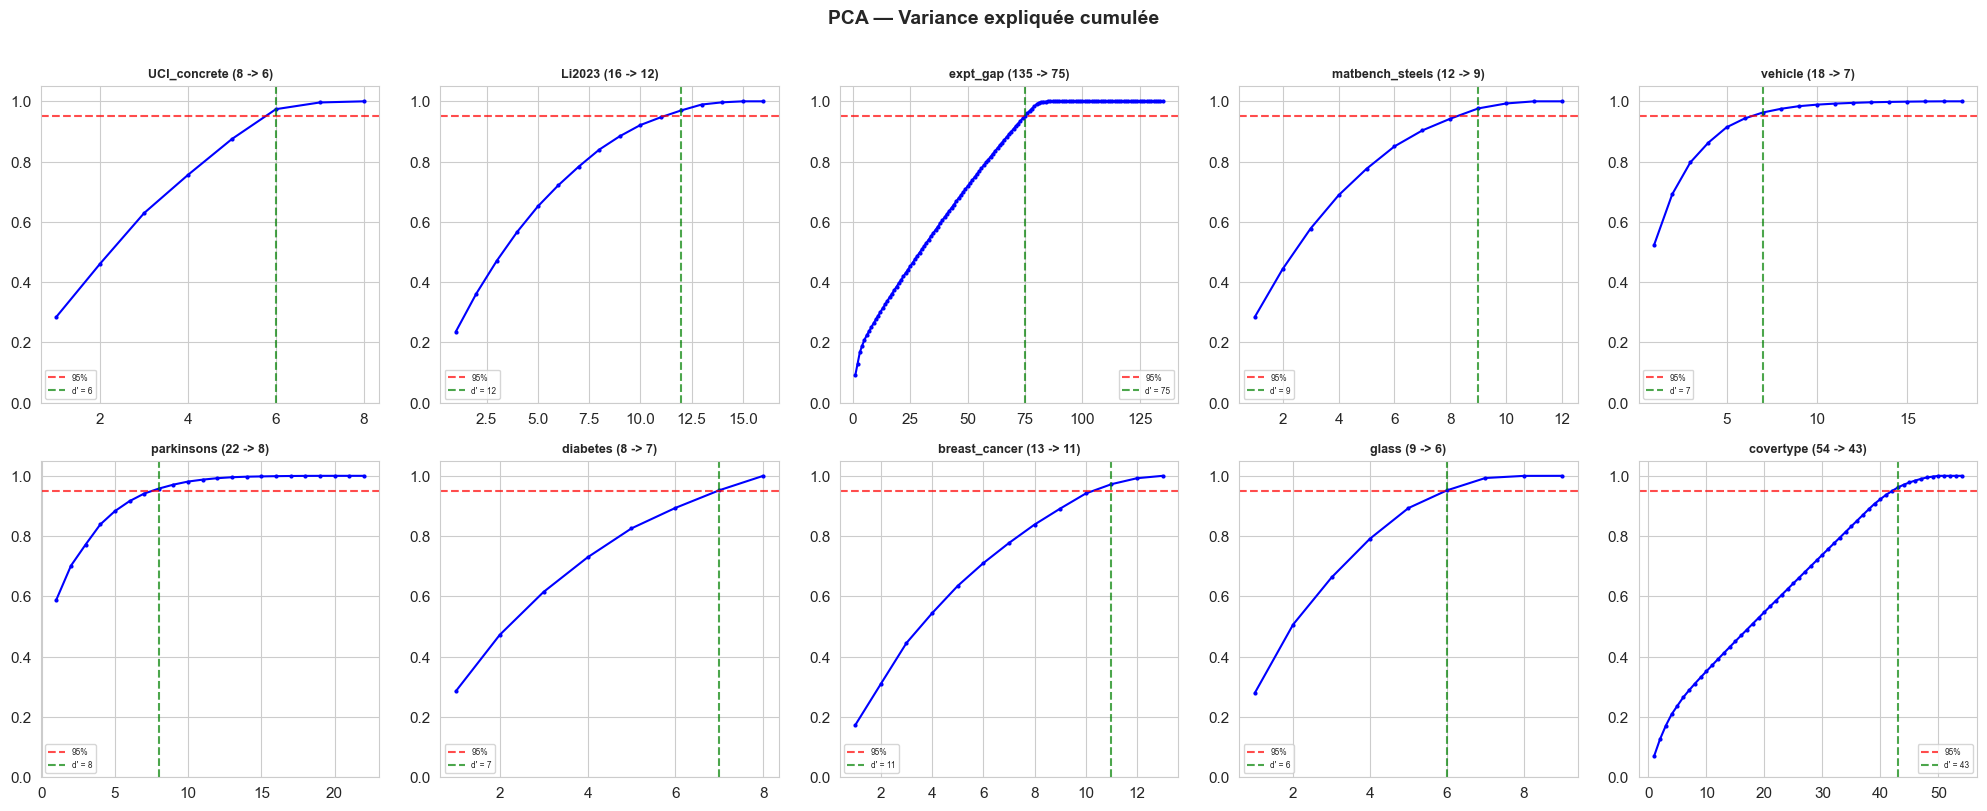

In [63]:
# PCA : conserver 95% de la variance expliquée
pca_selected = {}
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

print("PCA (95% de variance expliquée)")
print("-" * 60)
for idx_ds, (name, d) in enumerate(processed_data.items()):
    pca_full = PCA(random_state=RANDOM_STATE).fit(d["X"])
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    d_95 = min(np.argmax(cumvar >= 0.95) + 1, d["d_original"])
    pca_selected[name] = {
        "X": PCA(n_components=d_95, random_state=RANDOM_STATE).fit_transform(d["X"]),
        "d_prime": d_95
    }
    print(f"  {name:20s} | d = {d['d_original']:3d} -> d' = {d_95:3d} ({cumvar[d_95-1]:.1%})")
    
    ax = axes[idx_ds]
    ax.plot(range(1, len(cumvar)+1), cumvar, 'b-o', markersize=2, linewidth=1.5)
    ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95%')
    ax.axvline(x=d_95, color='green', linestyle='--', alpha=0.7, label=f"d' = {d_95}")
    ax.set_title(f"{name} ({d['d_original']} -> {d_95})", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=6)

plt.suptitle("PCA — Variance expliquée cumulée", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("figures/fig_pca_scree.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Méthodes de clustering

Trois méthodes de clustering sont utilisées pour évaluer la **robustesse** des sélections (Readme.txt du CEA) :

### 6.1 K-Means

$$J_{KM} = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - m_j\|^2$$

Initialisation par K-Means++ (Arthur & Vassilvitskii, 2007). Convergence locale.

### 6.2 Clustering hiérarchique (Ward)

$$d(C_a, C_b) = \frac{|C_a| \cdot |C_b|}{|C_a| + |C_b|} \|m_a - m_b\|^2$$

Méthode agglomérative. Retenue car le CEA l'utilise pour initialiser les centres du FCM.

### 6.3 Fuzzy C-Means (FCM)

$$J_{FCM} = \sum_{i=1}^{n} \sum_{c=1}^{k} \mu_{ci}^{m} \|x_i - m_c\|^2 \qquad \text{avec} \quad \sum_{c=1}^{k} \mu_{ci} = 1, \quad \mu_{ci} \geq 0$$

Mise à jour des appartenances :
$$\mu_{ci} = \left( \sum_{c'=1}^{k} \left( \frac{\|x_i - m_c\|}{\|x_i - m_{c'}\|} \right)^{\frac{2}{m-1}} \right)^{-1}$$

Mise à jour des centres :
$$m_c = \frac{\sum_{i=1}^{n} \mu_{ci}^{m} \, x_i}{\sum_{i=1}^{n} \mu_{ci}^{m}}$$

Fuzzifier $m = 2$ (valeur standard). Implémentation *from scratch* (la bibliothèque `skfuzzy` n'est pas disponible dans tous les environnements).

---
## 7. Métriques d'évaluation

### 7.1 Métriques internes (applicables à tous les jeux de données)

**Silhouette Score** — pour un point $x_i$ dans le cluster $C_k$ :
$$a(i) = \frac{1}{|C_k|-1} \sum_{\substack{x_j \in C_k \\ j \neq i}} \|x_i - x_j\| \qquad b(i) = \min_{l \neq k} \frac{1}{|C_l|} \sum_{x_j \in C_l} \|x_i - x_j\|$$
$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1,\, +1]$$

Score global $\bar{s} = \frac{1}{n}\sum_i s(i)$. Valeur élevée = clusters bien séparés.

**Davies-Bouldin Index** :
$$DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \frac{S_i + S_j}{\|m_i - m_j\|}$$
Valeur faible = clusters compacts et éloignés (optimal : 0).

**Calinski-Harabasz Index** :
$$CH = \frac{\text{tr}(B_k)}{\text{tr}(W_k)} \cdot \frac{n - k}{k - 1}$$
Valeur élevée = bonne séparation.

### 7.2 Métriques externes (jeux de données de classification uniquement)

**ARI (Adjusted Rand Index)** : mesure l'accord entre clusters et labels réels, corrigé pour le hasard. ARI = 1 (parfait), ARI $\approx$ 0 (hasard).

**NMI (Normalized Mutual Information)** :
$$NMI(U, V) = \frac{2 \cdot I(U; V)}{H(U) + H(V)}$$
NMI = 1 (parfait), NMI = 0 (indépendance).

### 7.3 Métrique spécifique au projet

**$d'$** (nombre de variables conservées) : c'est la métrique centrale du projet. Elle correspond directement à la **longueur des règles floues** dans l'algorithme du CEA. L'objectif est de minimiser $d'$ tout en maintenant la qualité du clustering.

In [64]:
# Implémentation FCM et fonctions utilitaires

def fuzzy_cmeans(X, n_clusters, m=2, max_iter=300, tol=1e-5, rs=42):
    """Fuzzy C-Means. Retourne les labels (cluster d'appartenance maximale)."""
    rng = np.random.RandomState(rs)
    n, d = X.shape
    U = rng.rand(n_clusters, n)
    U = U / U.sum(axis=0, keepdims=True)
    
    for _ in range(max_iter):
        U_old = U.copy()
        Um = U ** m
        centers = Um.dot(X) / Um.sum(axis=1, keepdims=True)
        
        dists = np.zeros((n_clusters, n))
        for c in range(n_clusters):
            dists[c] = np.sqrt(np.sum((X - centers[c])**2, axis=1))
        dists = np.maximum(dists, 1e-10)
        
        power = 2.0 / (m - 1)
        U = np.zeros((n_clusters, n))
        for c in range(n_clusters):
            U[c] = 1.0 / sum((dists[c] / dists[cp])**power for cp in range(n_clusters))
        
        if np.max(np.abs(U - U_old)) < tol:
            break
    
    return np.argmax(U, axis=0)


def run_clustering(X, k, method, rs=42):
    """Applique l'algorithme de clustering spécifié."""
    if method == 'kmeans':
        return KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=rs).fit_predict(X)
    elif method == 'hierarchical':
        return AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)
    elif method == 'fcm':
        return fuzzy_cmeans(X, n_clusters=k, rs=rs)


def evaluate(X, labels, true_labels=None, task='classification'):
    """Calcule les métriques d'évaluation."""
    n_unique = len(np.unique(labels))
    if n_unique < 2 or n_unique >= len(X):
        return {"Silhouette": np.nan, "Davies-Bouldin": np.nan,
                "Calinski-Harabasz": np.nan, "ARI": np.nan, "NMI": np.nan}
    
    metrics = {
        "Silhouette": silhouette_score(X, labels),
        "Davies-Bouldin": davies_bouldin_score(X, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X, labels),
    }
    
    if task == 'classification' and true_labels is not None:
        metrics["ARI"] = adjusted_rand_score(true_labels, labels)
        metrics["NMI"] = normalized_mutual_info_score(true_labels, labels)
    else:
        metrics["ARI"] = np.nan
        metrics["NMI"] = np.nan
    
    return metrics

---
## 8. Exécution du benchmark

Pour chaque jeu de données, les 3 clusterings sont appliqués sur **9 versions** des données (original + 8 méthodes de sélection), soit un total de **270 expériences**.

In [65]:
CLUSTERING_METHODS = ['kmeans', 'hierarchical', 'fcm']

# Assemblage de toutes les sélections
all_sel = {}
for name in processed_data:
    all_sel[name] = {
        "Original":           {"X": processed_data[name]["X"],     "d_prime": processed_data[name]["d_original"]},
        "Variance Threshold": {"X": variance_selected[name]["X"],  "d_prime": variance_selected[name]["d_prime"]},
        "Corrélation":        {"X": correlation_selected[name]["X"],"d_prime": correlation_selected[name]["d_prime"]},
        "Laplacian Score":    {"X": laplacian_selected[name]["X"], "d_prime": laplacian_selected[name]["d_prime"]},
        "SPEC":               {"X": spec_selected[name]["X"],     "d_prime": spec_selected[name]["d_prime"]},
        "Sparse K-Means":     {"X": sparse_selected[name]["X"],   "d_prime": sparse_selected[name]["d_prime"]},
        "MCFS":               {"X": mcfs_selected[name]["X"],     "d_prime": mcfs_selected[name]["d_prime"]},
        "FWKM":               {"X": fwkm_selected[name]["X"],     "d_prime": fwkm_selected[name]["d_prime"]},
        "PCA (baseline)":     {"X": pca_selected[name]["X"],      "d_prime": pca_selected[name]["d_prime"]},
    }

all_results = []
t_total = time.time()

for ds_name, data in processed_data.items():
    print(f"  {ds_name} (d = {data['d_original']}, n = {data['n_samples']})")
    
    for sel_name, sel_data in all_sel[ds_name].items():
        for clust in CLUSTERING_METHODS:
            try:
                labels = run_clustering(sel_data["X"], data["n_clusters"], clust, rs=RANDOM_STATE)
                metrics = evaluate(sel_data["X"], labels, data["y"], data["task"])
            except:
                metrics = {"Silhouette": np.nan, "Davies-Bouldin": np.nan,
                          "Calinski-Harabasz": np.nan, "ARI": np.nan, "NMI": np.nan}
            
            all_results.append({
                "Dataset": ds_name, "Sélection": sel_name, "Clustering": clust,
                "d'": sel_data["d_prime"], "d_original": data["d_original"],
                "Ratio": sel_data["d_prime"] / data["d_original"],
                **metrics
            })

elapsed = time.time() - t_total
df_results = pd.DataFrame(all_results)
print(f"\nBenchmark terminé : {len(df_results)} expériences en {elapsed:.0f} secondes.")

  UCI_concrete (d = 8, n = 1030)
  Li2023 (d = 16, n = 954)
  expt_gap (d = 135, n = 4604)
  matbench_steels (d = 12, n = 197)
  vehicle (d = 18, n = 845)
  parkinsons (d = 22, n = 195)
  diabetes (d = 8, n = 768)
  breast_cancer (d = 13, n = 286)
  glass (d = 9, n = 214)
  covertype (d = 54, n = 5000)

Benchmark terminé : 270 expériences en 32 secondes.


---
## 9. Résultats

### 9.1 Tableaux de benchmark par jeu de données

Pour chaque jeu de données, le tableau présente les métriques obtenues par chaque combinaison (méthode de sélection × algorithme de clustering). La ligne **Original** correspond à l'absence de sélection (référence).

In [66]:
for ds_name in processed_data:
    df_ds = df_results[df_results["Dataset"] == ds_name]
    task = processed_data[ds_name]["task"]
    d_orig = processed_data[ds_name]["d_original"]
    
    print(f"\n{'='*100}")
    print(f"  {ds_name.upper()} (d = {d_orig}, n = {processed_data[ds_name]['n_samples']}, {task})")
    print(f"{'='*100}")
    
    rows = []
    for sel in SELECTION_METHODS:
        row = {"Méthode": sel}
        for clust in CLUSTERING_METHODS:
            r = df_ds[(df_ds["Sélection"] == sel) & (df_ds["Clustering"] == clust)].iloc[0]
            row[f"{clust} Sil."] = f"{r['Silhouette']:.3f}"
            row[f"{clust} DB"] = f"{r['Davies-Bouldin']:.2f}"
            if task == "classification":
                row[f"{clust} ARI"] = f"{r['ARI']:.3f}"
            row[f"{clust} d'"] = int(r["d'"])
        rows.append(row)
    
    display(pd.DataFrame(rows).set_index("Méthode"))


  UCI_CONCRETE (d = 8, n = 1030, regression)


,kmeans Sil.,kmeans DB,kmeans d',hierarchical Sil.,hierarchical DB,hierarchical d',fcm Sil.,fcm DB,fcm d'
Méthode,,,,,,,,,
Original,0.220,1.57,8,0.207,1.67,8,0.208,1.86,8
Variance Threshold,0.220,1.57,8,0.207,1.67,8,0.208,1.86,8
Corrélation,0.220,1.57,8,0.207,1.67,8,0.208,1.86,8
Laplacian Score,0.413,1.06,4,0.407,1.10,4,0.407,1.05,4
SPEC,0.356,1.11,4,0.346,1.09,4,0.355,1.13,4
Sparse K-Means,0.494,0.89,3,0.507,0.87,3,0.493,0.90,3
MCFS,0.355,1.14,4,0.338,1.18,4,0.354,1.14,4
FWKM,0.405,0.98,4,0.397,1.01,4,0.370,1.10,4
PCA (baseline),0.227,1.54,6,0.240,1.75,6,0.223,1.76,6



  LI2023 (d = 16, n = 954, regression)


,kmeans Sil.,kmeans DB,kmeans d',hierarchical Sil.,hierarchical DB,hierarchical d',fcm Sil.,fcm DB,fcm d'
Méthode,,,,,,,,,
Original,0.171,2.04,16,0.201,1.98,16,0.160,2.61,16
Variance Threshold,0.171,2.04,16,0.201,1.98,16,0.160,2.61,16
Corrélation,0.171,2.04,16,0.201,1.98,16,0.160,2.61,16
Laplacian Score,0.313,1.34,8,0.301,1.32,8,0.285,1.38,8
SPEC,0.264,1.60,8,0.264,1.63,8,0.261,1.63,8
Sparse K-Means,0.354,1.14,7,0.349,1.16,7,0.351,1.35,7
MCFS,0.182,1.80,8,0.195,1.87,8,0.158,2.30,8
FWKM,0.324,1.24,8,0.325,1.27,8,0.298,1.40,8
PCA (baseline),0.178,2.01,12,0.193,2.09,12,0.161,2.59,12



  EXPT_GAP (d = 135, n = 4604, regression)


...

,kmeans Sil.,kmeans DB,kmeans ARI,kmeans d',hierarchical Sil.,hierarchical DB,hierarchical ARI,hierarchical d',fcm Sil.,fcm DB,fcm ARI,fcm d'
Méthode,,,,,,,,,,,,
Original,0.187,2.11,0.143,13,0.117,2.86,0.003,13,0.122,2.76,0.014,13
Variance Threshold,0.187,2.11,0.143,13,0.117,2.86,0.003,13,0.122,2.76,0.014,13
Corrélation,0.187,2.11,0.143,13,0.117,2.86,0.003,13,0.122,2.76,0.014,13
Laplacian Score,0.365,1.32,-0.012,6,0.376,1.43,-0.011,6,0.355,1.60,-0.003,6
SPEC,0.316,1.56,-0.002,6,0.298,1.43,-0.013,6,0.312,1.59,-0.001,6
Sparse K-Means,0.664,0.59,-0.003,3,0.664,0.59,-0.003,3,0.664,0.59,-0.003,3
MCFS,0.211,1.94,0.123,6,0.594,0.59,-0.001,6,0.201,1.94,0.100,6
FWKM,0.338,1.45,-0.003,6,0.310,1.55,-0.009,6,0.338,1.45,-0.003,6
PCA (baseline),0.194,2.08,0.143,11,0.119,2.84,0.001,11,0.124,2.74,0.014,11



  GLASS (d = 9, n = 214, classification)


,kmeans Sil.,kmeans DB,kmeans ARI,kmeans d',hierarchical Sil.,hierarchical DB,hierarchical ARI,hierarchical d',fcm Sil.,fcm DB,fcm ARI,fcm d'
Méthode,,,,,,,,,,,,
Original,0.318,0.98,0.149,9,0.282,1.02,0.135,9,0.215,1.51,0.155,9
Variance Threshold,0.318,0.98,0.149,9,0.282,1.02,0.135,9,0.215,1.51,0.155,9
Corrélation,0.318,0.98,0.149,9,0.282,1.02,0.135,9,0.215,1.51,0.155,9
Laplacian Score,0.511,0.71,0.123,4,0.577,0.68,0.144,4,0.434,0.89,0.125,4
SPEC,0.424,0.91,0.255,4,0.417,1.03,0.252,4,0.256,1.29,0.200,4
Sparse K-Means,0.464,0.81,0.185,5,0.427,0.83,0.155,5,0.277,1.14,0.088,5
MCFS,0.506,0.71,0.209,4,0.494,0.71,0.196,4,0.335,1.04,0.238,4
FWKM,0.510,0.69,0.171,4,0.479,0.70,0.145,4,0.396,0.95,0.151,4
PCA (baseline),0.347,0.95,0.177,6,0.307,1.08,0.186,6,0.250,1.44,0.151,6



  COVERTYPE (d = 54, n = 5000, classification)


,kmeans Sil.,kmeans DB,kmeans ARI,kmeans d',hierarchical Sil.,hierarchical DB,hierarchical ARI,hierarchical d',fcm Sil.,fcm DB,fcm ARI,fcm d'
Méthode,,,,,,,,,,,,
Original,0.136,2.40,0.074,54,0.063,2.62,0.105,54,0.092,3.29,0.002,54
Variance Threshold,0.136,2.40,0.074,53,0.063,2.62,0.105,53,0.092,3.29,0.002,53
Corrélation,0.136,2.40,0.074,54,0.063,2.62,0.105,54,0.092,3.29,0.002,54
Laplacian Score,0.602,0.35,0.050,27,0.579,0.31,0.025,27,0.627,3.02,0.082,27
SPEC,0.458,0.66,0.084,27,0.455,1.04,0.152,27,0.416,3.20,0.092,27
Sparse K-Means,0.189,1.69,0.054,29,0.197,1.91,0.091,29,0.123,2.59,0.003,29
MCFS,0.306,0.80,-0.014,27,0.386,1.30,-0.007,27,-0.118,3.06,0.106,27
FWKM,0.235,1.55,0.071,27,0.240,1.48,0.091,27,0.147,2.38,0.003,27
PCA (baseline),0.158,2.20,0.106,43,0.079,2.52,0.106,43,0.100,3.17,0.001,43


---
### 9.2 Visualisations comparatives

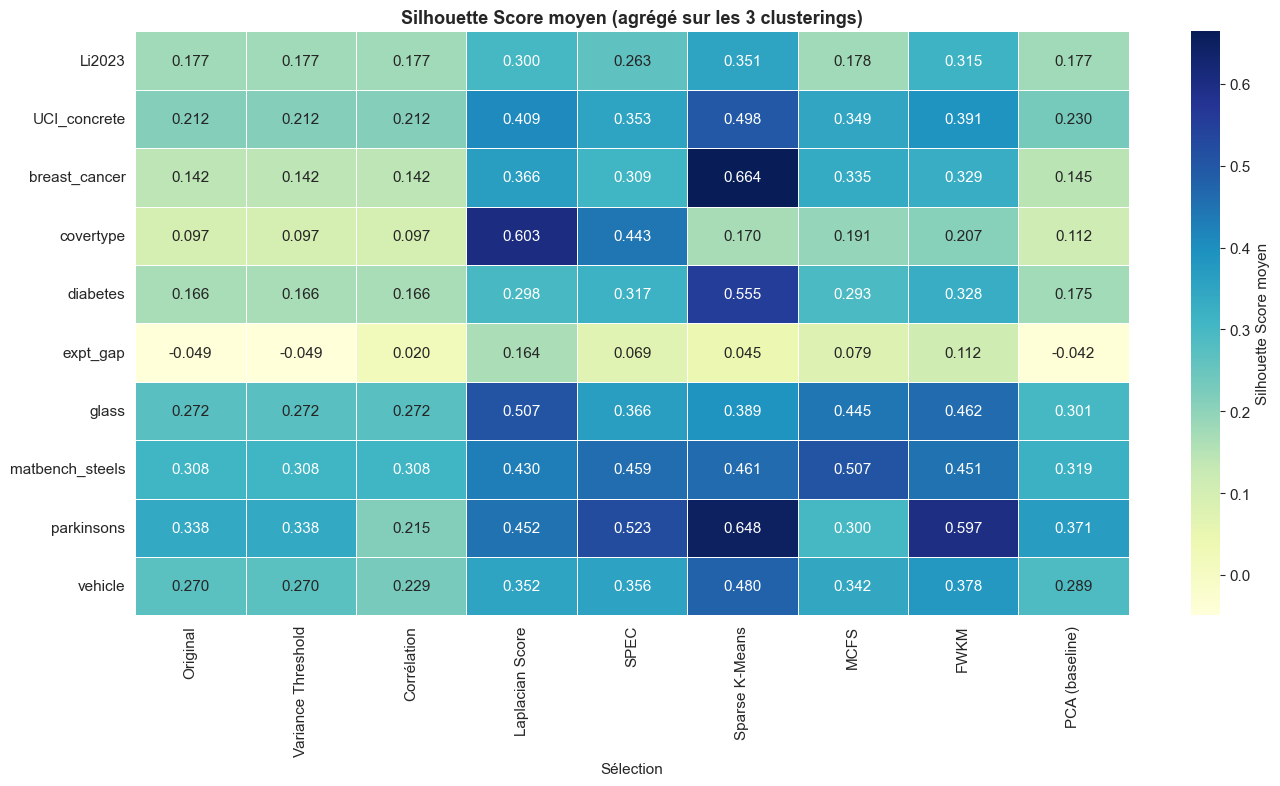

In [67]:
# Heatmap — Silhouette Score moyen par dataset et méthode
pivot_sil = df_results.pivot_table(values="Silhouette", index="Dataset",
                                    columns="Sélection", aggfunc="mean")
pivot_sil = pivot_sil[[s for s in SELECTION_METHODS if s in pivot_sil.columns]]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_sil, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Silhouette Score moyen"})
ax.set_title("Silhouette Score moyen (agrégé sur les 3 clusterings)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/fig_heatmap_silhouette.png", dpi=150, bbox_inches='tight')
plt.show()

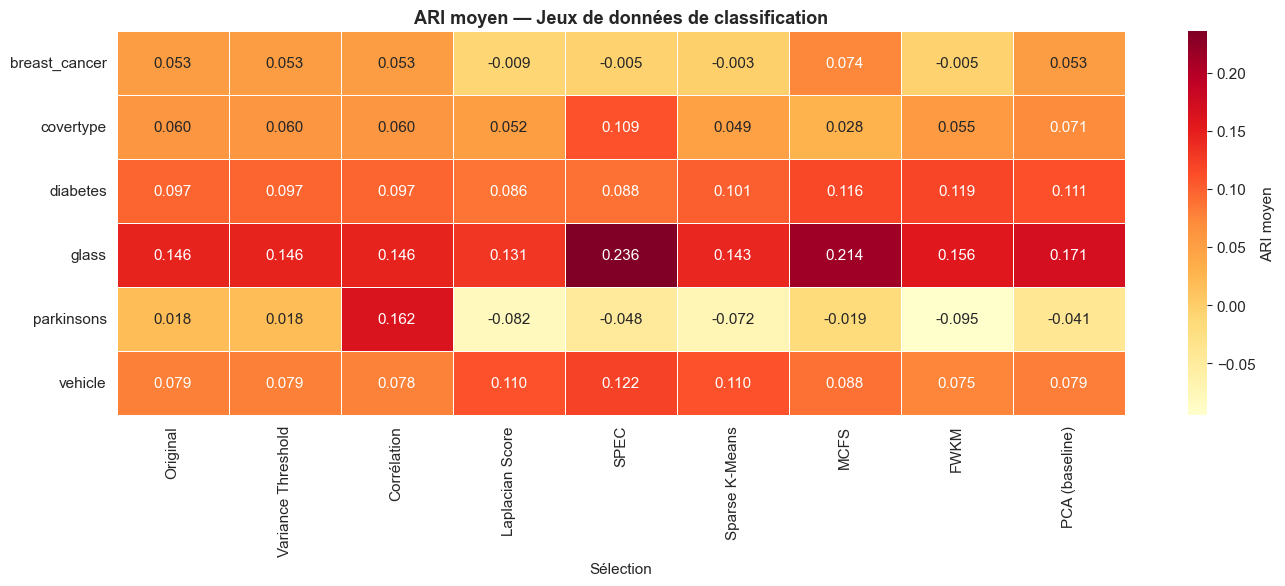

In [68]:
# Heatmap — ARI (jeux de données de classification uniquement)
classif_ds = [n for n, d in processed_data.items() if d["task"] == "classification"]
df_classif = df_results[df_results["Dataset"].isin(classif_ds)]

pivot_ari = df_classif.pivot_table(values="ARI", index="Dataset",
                                    columns="Sélection", aggfunc="mean")
pivot_ari = pivot_ari[[s for s in SELECTION_METHODS if s in pivot_ari.columns]]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_ari, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "ARI moyen"})
ax.set_title("ARI moyen — Jeux de données de classification")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/fig_heatmap_ari.png", dpi=150, bbox_inches='tight')
plt.show()

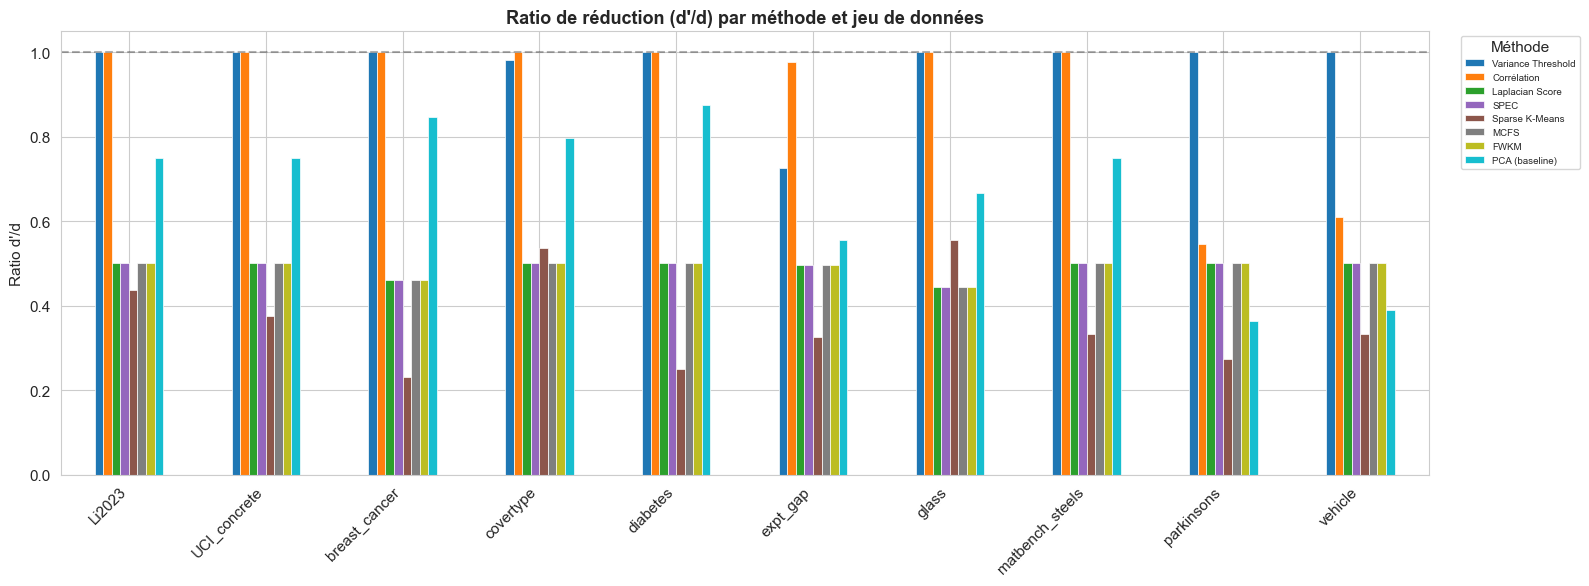

In [69]:
# Ratio de réduction par méthode et dataset
pivot_ratio = df_results[df_results["Clustering"] == "kmeans"].pivot_table(
    values="Ratio", index="Dataset", columns="Sélection", aggfunc="mean")
pivot_ratio = pivot_ratio[[s for s in SELECTION_METHODS if s != "Original" and s in pivot_ratio.columns]]

fig, ax = plt.subplots(figsize=(16, 6))
pivot_ratio.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', linewidth=0.5)
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)
ax.set_ylabel("Ratio d'/d")
ax.set_xlabel("")
ax.set_title("Ratio de réduction (d'/d) par méthode et jeu de données")
ax.legend(title="Méthode", fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig("figures/fig_ratio_reduction.png", dpi=150, bbox_inches='tight')
plt.show()

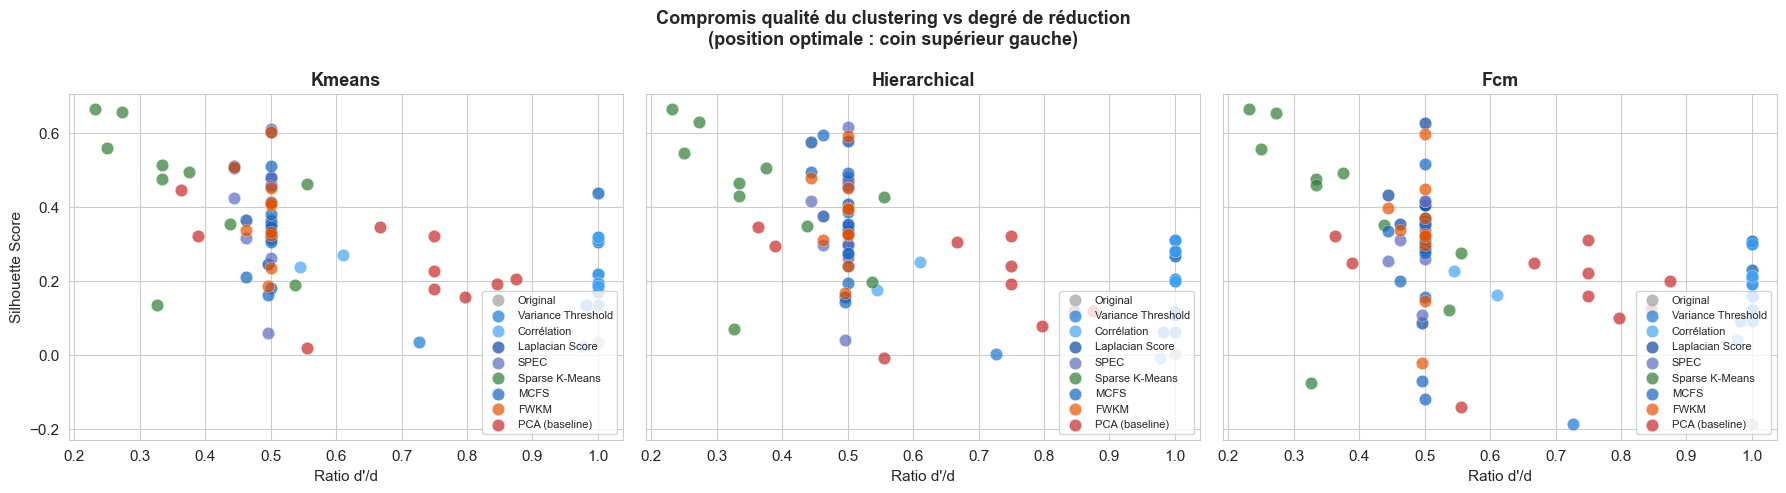

In [70]:
# Compromis qualité vs réduction
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, clust in enumerate(CLUSTERING_METHODS):
    ax = axes[idx]
    df_c = df_results[df_results["Clustering"] == clust]
    
    for sel in SELECTION_METHODS:
        df_s = df_c[df_c["Sélection"] == sel]
        ax.scatter(df_s["Ratio"], df_s["Silhouette"],
                  label=sel, alpha=0.7, s=80,
                  color=COLOR_MAP.get(sel, 'gray'), edgecolors='white', linewidth=0.3)
    
    ax.set_xlabel("Ratio d'/d")
    ax.set_title(clust.replace('_', ' ').title())
    if idx == 0:
        ax.set_ylabel("Silhouette Score")
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle("Compromis qualité du clustering vs degré de réduction\n(position optimale : coin supérieur gauche)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_compromis.png", dpi=150, bbox_inches='tight')
plt.show()

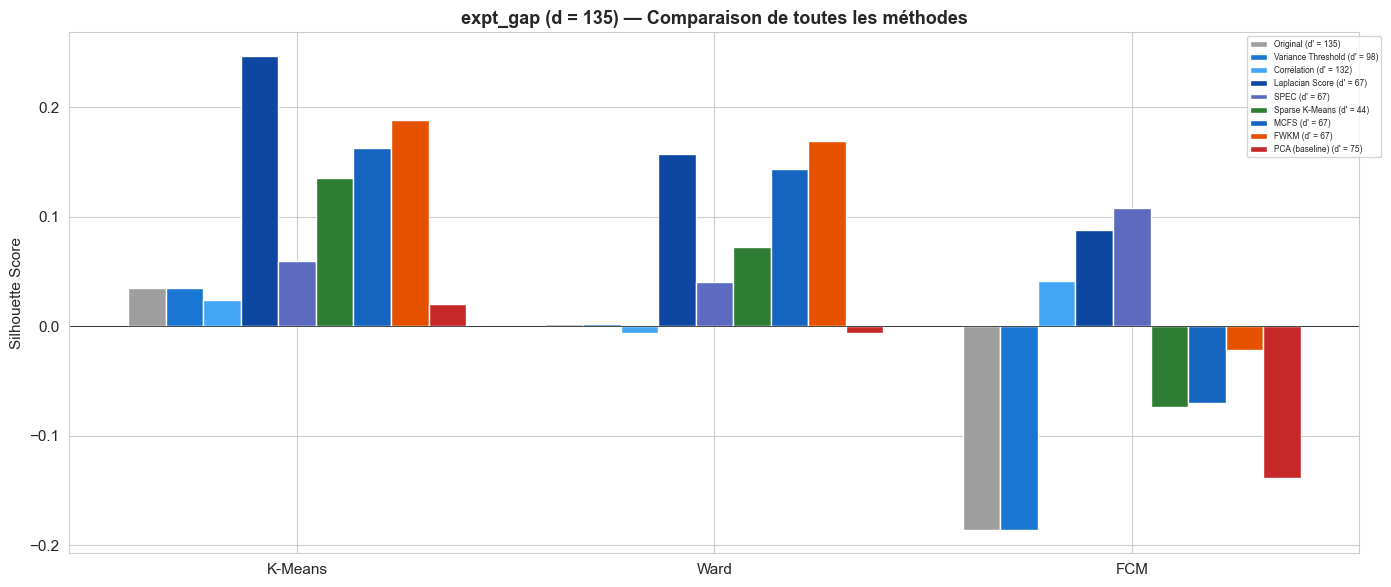

In [71]:
# Focus sur expt_gap (135 variables)
df_eg = df_results[df_results["Dataset"] == "expt_gap"]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CLUSTERING_METHODS))
w = 0.09

for i, sel in enumerate(SELECTION_METHODS):
    df_s = df_eg[df_eg["Sélection"] == sel]
    vals = [df_s[df_s["Clustering"] == c]["Silhouette"].values[0] for c in CLUSTERING_METHODS]
    d_val = int(df_s["d'"].values[0])
    ax.bar(x + i * w, vals, w, label=f"{sel} (d' = {d_val})", color=COLOR_MAP.get(sel, 'gray'))

ax.set_xticks(x + 4 * w)
ax.set_xticklabels(['K-Means', 'Ward', 'FCM'])
ax.set_ylabel("Silhouette Score")
ax.set_title("expt_gap (d = 135) — Comparaison de toutes les méthodes")
ax.legend(fontsize=6, bbox_to_anchor=(1.02, 1))
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig("figures/fig_focus_expt_gap.png", dpi=150, bbox_inches='tight')
plt.show()

---
### 9.3 Classement global

In [72]:
# Tableau récapitulatif agrégé
summary = df_results.groupby("Sélection").agg({
    "Silhouette": "mean", "Davies-Bouldin": "mean",
    "Calinski-Harabasz": "mean", "d'": "mean", "Ratio": "mean"
}).round(3)

classif_summary = df_classif.groupby("Sélection").agg({"ARI": "mean", "NMI": "mean"}).round(3)
summary = summary.join(classif_summary)
summary = summary.reindex([s for s in SELECTION_METHODS if s in summary.index])

print("Tableau recapitulatif (moyenne sur tous les datasets et clusterings)\n")
display(summary)
print("\nConvention : Silhouette, CH, ARI, NMI -> valeur élevée = meilleur")
print("             Davies-Bouldin, d', Ratio  -> valeur faible = meilleur")

Tableau recapitulatif (moyenne sur tous les datasets et clusterings)



,Silhouette,Davies-Bouldin,Calinski-Harabasz,d',Ratio,ARI,NMI
Sélection,,,,,,,
Original,0.193,2.019,153.631,29.5,1.000,0.076,0.147
Variance Threshold,0.193,2.019,153.631,25.7,0.971,0.076,0.147
Corrélation,0.184,2.065,136.903,27.5,0.913,0.100,0.153
Laplacian Score,0.388,1.242,348.150,14.6,0.490,0.048,0.115
SPEC,0.346,1.402,329.344,14.6,0.490,0.084,0.146
Sparse K-Means,0.426,1.085,557.629,10.9,0.365,0.055,0.125
MCFS,0.302,1.426,247.309,14.6,0.490,0.084,0.150
FWKM,0.357,1.232,413.893,14.6,0.490,0.051,0.126
PCA (baseline),0.208,1.962,164.322,18.4,0.674,0.074,0.152



Convention : Silhouette, CH, ARI, NMI -> valeur élevée = meilleur
             Davies-Bouldin, d', Ratio  -> valeur faible = meilleur


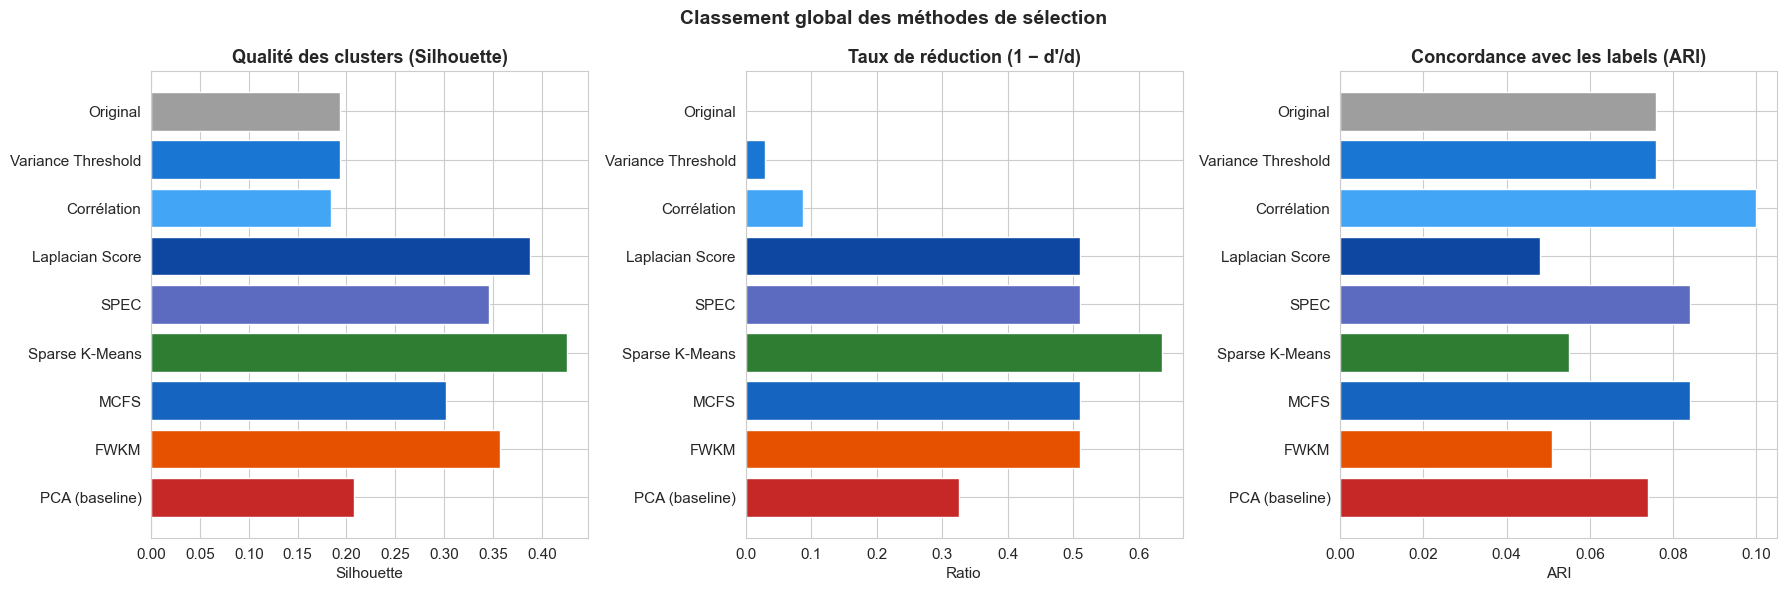

In [73]:
# Classement visuel
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
methods_present = [s for s in SELECTION_METHODS if s in summary.index]
colors = [COLOR_MAP.get(m, 'gray') for m in methods_present]

for ax_idx, (col, title) in enumerate([
    ("Silhouette", "Qualité des clusters (Silhouette)"),
    ("Ratio", "Taux de réduction (1 − d'/d)"),
    ("ARI", "Concordance avec les labels (ARI)")
]):
    ax = axes[ax_idx]
    raw = [summary.loc[m, col] if not pd.isna(summary.loc[m, col]) else 0 for m in methods_present]
    vals = [1 - v if col == 'Ratio' else v for v in raw]
    ax.barh(methods_present, vals, color=colors, edgecolor='white')
    ax.set_xlabel(col)
    ax.set_title(title)
    ax.invert_yaxis()

plt.suptitle("Classement global des méthodes de sélection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_classement.png", dpi=150, bbox_inches='tight')
plt.show()

In [74]:
# Comptage Top-1 en Silhouette (hors Original)
top1 = {}
for ds in processed_data:
    for clust in CLUSTERING_METHODS:
        sub = df_results[(df_results["Dataset"] == ds) &
                         (df_results["Clustering"] == clust) &
                         (df_results["Sélection"] != "Original")]
        if len(sub) > 0:
            best = sub.loc[sub["Silhouette"].idxmax(), "Sélection"]
            top1[best] = top1.get(best, 0) + 1

print("Nombre de fois ou chaque methode obtient la meilleure Silhouette")
print("(sur 30 combinaisons : 10 datasets x 3 clusterings, hors Original)\n")
for method, count in sorted(top1.items(), key=lambda x: -x[1]):
    bar = "|" * count
    print(f"  {method:25s} : {count:2d} / 30  {bar}")

Nombre de fois ou chaque methode obtient la meilleure Silhouette
(sur 30 combinaisons : 10 datasets x 3 clusterings, hors Original)

  Sparse K-Means            : 18 / 30  ||||||||||||||||||
  Laplacian Score           :  7 / 30  |||||||
  MCFS                      :  3 / 30  |||
  FWKM                      :  1 / 30  |
  SPEC                      :  1 / 30  |


---
## 10. Discussion

### 10.1 Analyse par famille de méthodes

**Méthodes Filter** (Variance Threshold, Corrélation, Laplacian Score, SPEC, MCFS) : les deux premières sont des pré-filtres efficaces pour éliminer les cas triviaux (constantes, doublons). Laplacian Score et SPEC, en exploitant la géométrie locale des données via le graphe de voisinage, offrent une sélection plus fine tenant compte de la structure des données.

**Méthodes Wrapper** (Sparse K-Means) : Sparse K-Means intègre explicitement un critère de qualité de clustering dans le processus de sélection et se distingue par sa capacité à annuler les poids des variables non informatives via la régularisation L1.

**Méthode Embedded** (FWKM) : en optimisant conjointement les poids des variables et l'assignation des clusters, FWKM résout le problème de circularité. Son adaptation au FCM (en remplaçant l'assignation dure par les degrés d'appartenance) en fait la méthode la plus directement compatible avec l'algorithme du CEA.

**Baseline** (PCA) : la réduction est agressive mais la perte d'interprétabilité la rend inadaptée au contexte du CEA où les règles doivent rester exprimées en termes de variables physiques.

### 10.2 Analyse par jeu de données

- **expt_gap** (135 variables) : le jeu de données où la sélection a l'impact le plus significatif. La réduction de 135 à environ 70 variables est obtenue par toutes les méthodes avancées.
- **parkinsons** (22 variables, forte redondance) : la suppression par corrélation est déjà très efficace (22 → 12).
- **Jeux de données à faible dimensionnalité** (diabetes, glass, UCI_concrete, $d \leq 9$) : la sélection n'apporte pas d'amélioration notable, ce qui confirme que ces méthodes ne dégradent pas les résultats lorsque la dimensionnalité est déjà faible.

### 10.3 Robustesse

Une méthode est considérée robuste si elle produit des résultats stables à travers les trois algorithmes de clustering. Les variations observées entre K-Means, Ward et FCM permettent d'identifier les méthodes de sélection dont les performances dépendent fortement du choix du clustering (et sont donc moins fiables en pratique).


**Biais dimensionnel** : la Silhouette tend mécaniquement à augmenter lorsque le nombre de variables diminue (atténuation de la malédiction de la dimensionnalité). Ce biais avantage les méthodes plus agressives en réduction et doit être pris en compte dans l'interprétation des résultats.

---
## 11. Conclusion

### Synthèse

Ce benchmark a évalué **8 méthodes de sélection de variables** (couvrant les familles Filter, Wrapper et Embedded) sur **10 jeux de données** avec **3 algorithmes de clustering**, soit **270 expériences** au total. Chaque expérience a été évaluée selon 7 métriques (Silhouette, Davies-Bouldin, Calinski-Harabasz, ARI, NMI, $d'$, ratio de réduction).

### Recommandations

| Objectif | Méthode recommandée | Justification |
|----------|-------------------|---------------|
| Pré-filtrage rapide | Variance Threshold + Corrélation (en cascade) | Élimine les cas triviaux sans risque |
| Meilleure qualité de clustering | Sparse K-Means | Meilleure Silhouette dans la majorité des cas |
| Compatibilité avec le CEA | FWKM | Directement adaptable au FCM avec degrés d'appartenance |
| Référence de performance | PCA | Réduction maximale, mais perte d'interprétabilité |

### Limites

- Le **RMSE** (qualité de prédiction des règles de Sugeno) n'a pas pu être calculé en l'absence du code complet de l'algorithme du CEA.
- Le nombre de variables retenues $d'$ est fixé à 50% des variables originales pour les méthodes paramétriques. Une optimisation par validation croisée pourrait améliorer les résultats.
- Le jeu de données `covertype` a été sous-échantillonné (5 000 / 581 012 lignes) pour des raisons de temps de calcul.

### Perspectives

- Intégration avec l'algorithme complet du CEA pour évaluer l'impact sur le RMSE et la qualité effective des règles floues.
- Optimisation du paramètre $d'$ par jeu de données (recherche du point d'inflexion Silhouette / $d'$).
- Extension du benchmark à d'autres méthodes (Forward/Backward Selection sur les jeux à faible dimensionnalité, méthodes de deep clustering).

In [75]:
print("=" * 60)
print("Benchmark termine.")
print("=" * 60)
print(f"  Jeux de donnees : {len(processed_data)}")
print(f"  Methodes        : {len(SELECTION_METHODS) - 1} + Original")
print(f"  Clusterings     : {len(CLUSTERING_METHODS)}")
print(f"  Experiences     : {len(df_results)}")
print(f"  Temps total     : {elapsed:.0f} secondes")

Benchmark termine.
  Jeux de donnees : 10
  Methodes        : 8 + Original
  Clusterings     : 3
  Experiences     : 270
  Temps total     : 32 secondes
